# ForecastLLM - Week 7 Day 2: Prompt Dataset and Base Model

This notebook adapts the original Week 7 Day 2 data-prep flow from pricing to forecasting.

## What changed vs. original

- Replaced product items with time-series forecasting rows from Week 6-style features.
- Built prompt/completion datasets for train/validation/test splits.
- Kept token-length analysis, truncation cutoff, and optional Hugging Face push.

## Order Of Play

This notebook uses local M4 hourly data by default. Synthetic data is not used as an automatic fallback; missing M4 data should fail loudly so results are reproducible.

DAY 1: QLoRA setup
DAY 2: Prompt data and base model (this notebook)
DAY 3: Train part 1
DAY 4: Train part 2
DAY 5: Eval

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import Dataset, DatasetDict
from huggingface_hub import login
from transformers import AutoTokenizer
from dotenv import load_dotenv

from week6.data_loader import load_sample_series

In [2]:
load_dotenv()

LITE_MODE = os.getenv("LITE_MODE", "0").lower() in {"1", "true", "yes"}

BASE_MODEL = os.getenv("BASE_MODEL", "TinyLlama/TinyLlama-1.1B-Chat-v1.0")
HF_TOKEN = os.getenv("HF_TOKEN", "")
HF_USERNAME = os.getenv("HF_USERNAME", "")

print(f"LITE_MODE={LITE_MODE}")
print(f"BASE_MODEL={BASE_MODEL}")
print(f"FORECAST_DATA_PATH={os.getenv('FORECAST_DATA_PATH')}")

if HF_TOKEN:
    login(HF_TOKEN, add_to_git_credential=True)
    print("Hugging Face authentication configured from HF_TOKEN.")
else:
    print("HF_TOKEN not set; continuing without hub authentication.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


LITE_MODE=False
BASE_MODEL=TinyLlama/TinyLlama-1.1B-Chat-v1.0
FORECAST_DATA_PATH=/home/geo/Projects/Python/forecastllm/data/m4/processed/hourly_longest_series.csv
Hugging Face authentication configured from HF_TOKEN.


In [3]:
try:
    ts_df = load_sample_series()
except Exception as exc:
    raise RuntimeError(
        "Failed to load local M4 hourly data. "
        "Set FORECAST_DATA_PATH in .env or place the M4 hourly CSV at the documented default path."
    ) from exc

if not isinstance(ts_df, pd.DataFrame):
    raise TypeError(f"load_sample_series must return a pandas DataFrame, got {type(ts_df)}")
if not {"timestamp", "value"}.issubset(ts_df.columns):
    raise ValueError("Loaded dataframe must include 'timestamp' and 'value' columns")

ts_df = ts_df[["timestamp", "value"]].copy()
ts_df["timestamp"] = pd.to_datetime(ts_df["timestamp"], errors="coerce")
ts_df["value"] = pd.to_numeric(ts_df["value"], errors="coerce")
ts_df = ts_df.dropna(subset=["timestamp", "value"]).sort_values("timestamp").reset_index(drop=True)

if len(ts_df) < 90:
    raise RuntimeError(f"Need at least 90 usable rows, got {len(ts_df)}")

print(f"Loaded {len(ts_df):,} rows")
print(ts_df.head())

Loaded 960 rows
            timestamp  value
0 2000-01-01 00:00:00   12.8
1 2000-01-01 01:00:00   12.1
2 2000-01-01 02:00:00   11.6
3 2000-01-01 03:00:00   11.2
4 2000-01-01 04:00:00   10.8


In [4]:
# Build supervised lag/calendar features (hourly protocol)
supervised_df: pd.DataFrame = ts_df.copy()
supervised_df["lag_1"] = supervised_df["value"].shift(1)
supervised_df["lag_24"] = supervised_df["value"].shift(24)
supervised_df["lag_168"] = supervised_df["value"].shift(168)
supervised_df["hour_of_day"] = supervised_df["timestamp"].dt.hour
supervised_df["day_of_week"] = supervised_df["timestamp"].dt.dayofweek
supervised_df = supervised_df.dropna().reset_index(drop=True)

if LITE_MODE:
    supervised_df = supervised_df.tail(min(len(supervised_df), 160)).reset_index(drop=True)

n = len(supervised_df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df: pd.DataFrame = supervised_df.iloc[:train_end].copy()
val_df: pd.DataFrame = supervised_df.iloc[train_end:val_end].copy()
test_df: pd.DataFrame = supervised_df.iloc[val_end:].copy()

print(f"Train={len(train_df):,}, Val={len(val_df):,}, Test={len(test_df):,}")
print(train_df.head())

Train=554, Val=119, Test=119
            timestamp  value  lag_1  lag_24  lag_168  hour_of_day  day_of_week
0 2000-01-08 00:00:00   13.5   13.7    13.5     12.8            0            5
1 2000-01-08 01:00:00   12.8   13.5    12.7     12.1            1            5
2 2000-01-08 02:00:00   12.3   12.8    12.3     11.6            2            5
3 2000-01-08 03:00:00   11.9   12.3    11.8     11.2            3            5
4 2000-01-08 04:00:00   11.6   11.9    11.4     10.8            4            5


In [5]:
if AutoTokenizer is None:
    raise RuntimeError("AutoTokenizer is unavailable")

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
if tokenizer is None:
    raise RuntimeError(f"Tokenizer load failed for {BASE_MODEL}")

if getattr(tokenizer, "pad_token", None) is None and getattr(tokenizer, "eos_token", None) is not None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded:", BASE_MODEL)

Tokenizer loaded: TinyLlama/TinyLlama-1.1B-Chat-v1.0


In [6]:
def feature_summary(row):
    return (
        f"timestamp={row['timestamp']}, lag_1={row['lag_1']:.3f}, lag_24={row['lag_24']:.3f}, "
        f"lag_168={row['lag_168']:.3f}, hour_of_day={int(row['hour_of_day'])}, day_of_week={int(row['day_of_week'])}"
    )

def extract_input_ids(encoded) -> list[int]:
    if not hasattr(encoded, "get"):
        raise RuntimeError("Tokenizer output does not expose .get")
    raw_ids = encoded.get("input_ids")
    if raw_ids is None:
        raise RuntimeError("Tokenizer output missing input_ids")
    if isinstance(raw_ids, np.ndarray):
        return [int(x) for x in raw_ids.tolist()]
    return [int(x) for x in raw_ids]

all_rows = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)
summaries = [feature_summary(row) for _, row in all_rows.iterrows()]

tokenizer_call = getattr(tokenizer, "__call__", None)
if tokenizer_call is None:
    raise RuntimeError("Tokenizer is not callable")

token_counts: list[int] = [
    len(extract_input_ids(tokenizer_call(text, add_special_tokens=False)))
    for text in tqdm(summaries)
]

print(f"Summary token stats: avg={np.mean(token_counts):.1f}, p95={np.percentile(token_counts, 95):.1f}, max={np.max(token_counts)}")

  0%|          | 0/792 [00:00<?, ?it/s]

Summary token stats: avg=73.6, p95=74.0, max=74


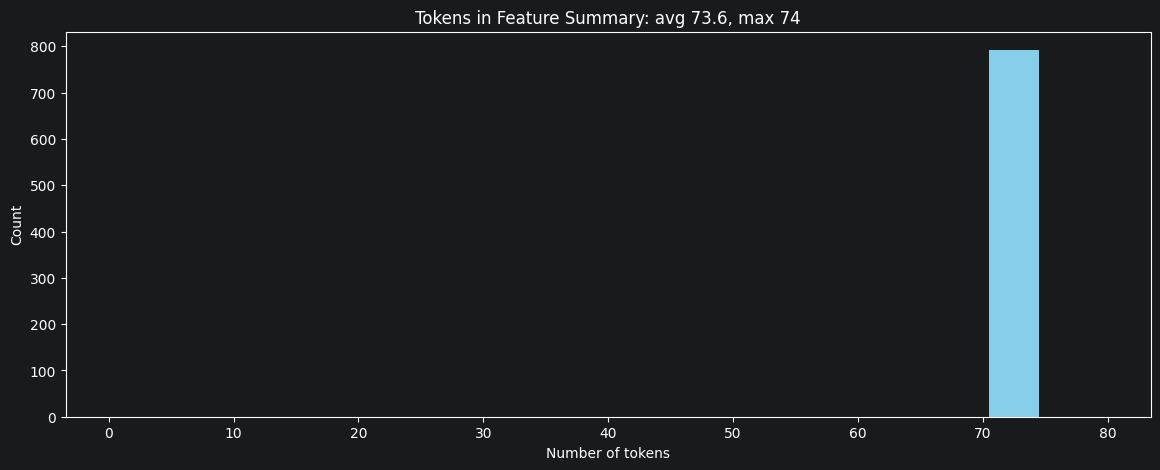

In [7]:
if not token_counts:
    raise RuntimeError("token_counts is empty")

max_token_count = int(max(token_counts))

plt.figure(figsize=(14, 5))
plt.title(f"Tokens in Feature Summary: avg {np.mean(token_counts):,.1f}, max {np.max(token_counts):,}")
plt.xlabel("Number of tokens")
plt.ylabel("Count")
plt.hist(token_counts, rwidth=0.8, color="skyblue", bins=range(0, max_token_count + 10, 5))
plt.show()

In [8]:
CUTOFF = int(np.percentile(token_counts, 95))
truncated = sum(count > CUTOFF for count in token_counts)
print(f"CUTOFF={CUTOFF}. Truncating {truncated:,}/{len(token_counts):,} rows ({truncated/len(token_counts):.1%}).")

CUTOFF=74. Truncating 0/792 rows (0.0%).


In [9]:
def truncate_to_tokens(text: str, tok, cutoff: int) -> str:
    tok_call = getattr(tok, "__call__", None)
    if tok_call is None:
        raise RuntimeError("Tokenizer is not callable")

    ids = extract_input_ids(tok_call(text, add_special_tokens=False))
    if len(ids) <= cutoff:
        return text

    decode_fn = getattr(tok, "decode", None)
    if decode_fn is None:
        raise RuntimeError("Tokenizer decode is unavailable")

    trimmed = ids[:cutoff]
    return decode_fn(trimmed, skip_special_tokens=True)

def build_prompt_from_row(row, tok, cutoff: int) -> str:
    summary = truncate_to_tokens(feature_summary(row), tok, cutoff)
    return (
        "You are a forecasting assistant.\n"
        "Given the following recent-series context, predict the next hourly value.\n"
        f"{summary}\n"
        "Return only a numeric forecast."
    )

def build_completion_from_row(row) -> str:
    return f"{row['value']:.3f}"

def make_records(df: pd.DataFrame, include_completion: bool) -> list[dict[str, str]]:
    records: list[dict[str, str]] = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        prompt = build_prompt_from_row(row, tokenizer, CUTOFF)
        completion = build_completion_from_row(row)
        record: dict[str, str] = {"prompt": prompt, "completion": completion}
        if include_completion:
            record["text"] = f"{prompt}\n{completion}"
        else:
            record["text"] = prompt
        records.append(record)
    return records

In [10]:
train_records: list[dict[str, str]] = make_records(train_df, include_completion=True)
val_records: list[dict[str, str]] = make_records(val_df, include_completion=True)
test_records: list[dict[str, str]] = make_records(test_df, include_completion=False)
all_records: list[dict[str, str]] = [*train_records, *val_records, *test_records]

print(
    f"Prepared prompt records: train={len(train_records):,}, val={len(val_records):,}, test={len(test_records):,}"
)

  0%|          | 0/554 [00:00<?, ?it/s]

  0%|          | 0/119 [00:00<?, ?it/s]

  0%|          | 0/119 [00:00<?, ?it/s]

Prepared prompt records: train=554, val=119, test=119


In [11]:
if not test_records:
    raise RuntimeError("test_records is empty")

sample_record: dict[str, str] = test_records[0]

print("PROMPT:\n")
print(sample_record["prompt"])
print("\nCOMPLETION (held out target):")
print(sample_record["completion"])

PROMPT:

You are a forecasting assistant.
Given the following recent-series context, predict the next hourly value.
timestamp=2000-02-05 01:00:00, lag_1=18.800, lag_24=18.200, lag_168=16.700, hour_of_day=1, day_of_week=5
Return only a numeric forecast.

COMPLETION (held out target):
18.300


  0%|          | 0/792 [00:00<?, ?it/s]

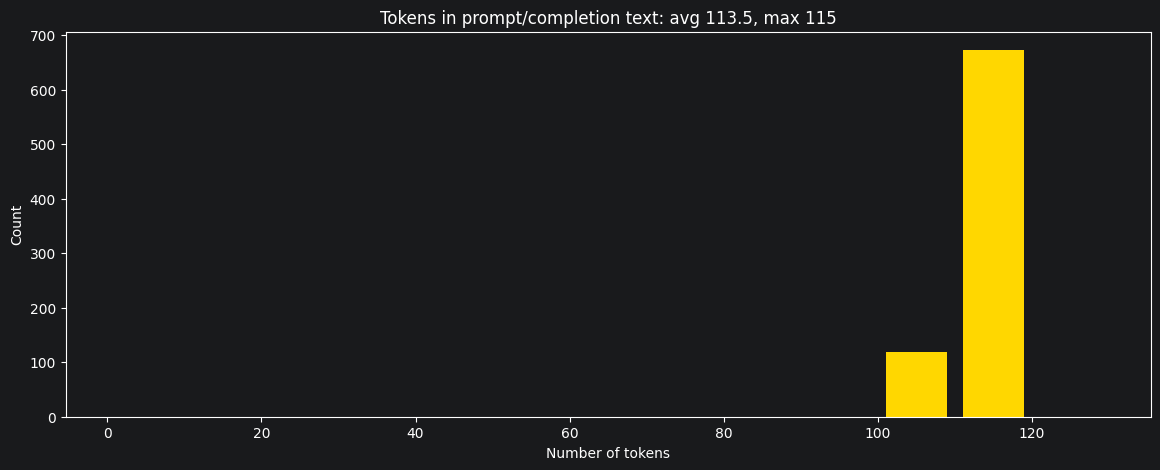

In [12]:
tokenizer_call = getattr(tokenizer, "__call__", None)
if tokenizer_call is None:
    raise RuntimeError("Tokenizer is not callable")

prompt_token_counts: list[int] = [
    len(extract_input_ids(tokenizer_call(record["text"], add_special_tokens=False)))
    for record in tqdm(all_records)
]

if not prompt_token_counts:
    raise RuntimeError("prompt_token_counts is empty")

max_prompt_token_count = int(max(prompt_token_counts))

plt.figure(figsize=(14, 5))
plt.title(f"Tokens in prompt/completion text: avg {np.mean(prompt_token_counts):,.1f}, max {np.max(prompt_token_counts):,}")
plt.xlabel("Number of tokens")
plt.ylabel("Count")
plt.hist(prompt_token_counts, rwidth=0.8, color="gold", bins=range(0, max_prompt_token_count + 20, 10))
plt.show()

In [13]:
dataset_dict = DatasetDict({
    "train": Dataset.from_pandas(pd.DataFrame(train_records), preserve_index=False),
    "validation": Dataset.from_pandas(pd.DataFrame(val_records), preserve_index=False),
    "test": Dataset.from_pandas(pd.DataFrame(test_records), preserve_index=False),
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['prompt', 'completion', 'text'],
        num_rows: 554
    })
    validation: Dataset({
        features: ['prompt', 'completion', 'text'],
        num_rows: 119
    })
    test: Dataset({
        features: ['prompt', 'completion', 'text'],
        num_rows: 119
    })
})

In [14]:
if HF_USERNAME:
    dataset_name = f"{HF_USERNAME}/forecast_prompts_lite" if LITE_MODE else f"{HF_USERNAME}/forecast_prompts_full"
    if HF_TOKEN:
        dataset_dict.push_to_hub(dataset_name)
        print(f"Uploaded dataset to: https://huggingface.co/datasets/{dataset_name}")
    else:
        print("HF_USERNAME set but HF_TOKEN missing; skipping push_to_hub.")
        print("Would upload dataset:", dataset_name)
else:
    print("HF_USERNAME not set; skipping push_to_hub.")

HF_USERNAME not set; skipping push_to_hub.


## Day 2 Wrap-up

- Created forecasting prompt/completion datasets for train/validation/test.
- Measured token lengths, selected a truncation cutoff, and regenerated prompts accordingly.
- Prepared a `DatasetDict` suitable for Day 3/4 fine-tuning.
- Optional Hugging Face upload is supported via `HF_USERNAME` + `HF_TOKEN`.